# KAT-style In-Context Imitation Learning — ACT Transfer Cube

End-to-end runnable notebook on the **`sim_transfer_cube_scripted`** task.
## Prereqs


```bash
uv venv .venv --python 3.9
source .venv/bin/activate
uv pip install -r requirements-kat.txt   # single consolidated requirements file
cd detr && pip install -e . && cd ..
python3 scripts/download_dino_weights.py

ollama serve && ollama pull gemma4:26b && ollama pull llama3.2:latest
```

Every cell below shells out via `source .venv/bin/activate && python3 …` so the **uv-managed** venv at `./.venv` is the interpreter used for sim, DINO, and Ollama calls. Equivalent one-shot CLI:

```bash
source .venv/bin/activate
python3 record_sim_episodes.py --task_name sim_transfer_cube_scripted \
    --dataset_dir data/transfer_cube/base --num_episodes 25 \
    --downsample_rate 10 --seed 0
python3 scripts/make_subsets.py --base_dir data/transfer_cube/base
python3 scripts/evaluate.py sweep --collection_seed 0 \
    --models 'gemma4:26b,llama3.2:latest'
```

**Notebook map**

| Step | Purpose | Saves to `artifacts/` |
|------|---------|------------------------|
| 1 | Environment smoke + short rendering video | `step1_env_smoke.mp4` |
| 2 | Dataset (25 episodes, seed 0) + visualize one episode | `data/transfer_cube/base/episode_0_video.mp4` |
| 3 | KAT tokenization sanity (tokens, KP overlay, GT replay) | `keypoints_overlay.png`, `replays/gt_*.mp4`, `results_gt_replay_*.csv` |
| 4 | Single ICL smoke (Ollama → JSON → replay) | `prompts/`, `responses/`, `replays/` for one query |
| 5 | Full sweep: seen + unseen + 4 ablations + aggregate | `results_*.csv`, `evaluation_summary.json`, `evaluation_tables.md` |

In [1]:
import os, sys, subprocess, json, glob
from pathlib import Path
from IPython.display import Image, Video, Markdown, display

ROOT = Path(os.getcwd()).resolve()
VENV_PY = ROOT / '.venv' / 'bin' / 'python3'
ACTIVATE = f"source {ROOT}/.venv/bin/activate"
DATA_BASE = ROOT / 'data' / 'transfer_cube' / 'base'
SUBSETS = ROOT / 'data' / 'transfer_cube' / 'subsets'
ARTIFACTS = ROOT / 'artifacts'
ARTIFACTS.mkdir(exist_ok=True)
(ARTIFACTS / 'replays').mkdir(exist_ok=True)

COLLECTION_SEED = 0
OLLAMA_MODEL = os.environ.get('OLLAMA_MODEL', 'gemma4:26b')

def run(cmd, check=True):
    """Run a shell command via bash -lc so the uv venv activation sticks."""
    print(f'$ {cmd}')
    r = subprocess.run(['bash', '-lc', cmd], cwd=str(ROOT))
    if check and r.returncode != 0:
        raise RuntimeError(f'cmd failed (exit {r.returncode}): {cmd}')
    return r.returncode

def _rel(path):
    p = Path(path)
    if not p.is_absolute():
        p = (ROOT / p).resolve()
    try:
        return p.relative_to(ROOT)
    except ValueError:
        return p

def show_video(path, width=480):
    p = _rel(path)
    abs_p = p if p.is_absolute() else (ROOT / p)
    if not abs_p.exists():
        print(f'(missing: {p})'); return
    display(Video(filename=str(abs_p), embed=True, width=width, mimetype='video/mp4'))

def show_image(path, width=480):
    p = _rel(path)
    abs_p = p if p.is_absolute() else (ROOT / p)
    if not abs_p.exists():
        print(f'(missing: {p})'); return
    display(Image(filename=str(abs_p), width=width))

print('python :', sys.executable)
print('venv py:', VENV_PY, 'exists' if VENV_PY.exists() else 'MISSING')
print('cwd    :', ROOT)
print('ollama :', OLLAMA_MODEL)

python : /Users/sushantsubedi/Documents/act/.venv/bin/python
venv py: /Users/sushantsubedi/Documents/act/.venv/bin/python3 exists
cwd    : /Users/sushantsubedi/Documents/act
ollama : gemma4:26b


## Step 1 — Environment smoke test + render a real demo video

Runs the **scripted pick-and-transfer policy** end-to-end (`episode_len = 400` sim steps) in `ee_sim_env` and saves the full overhead-camera rendering to `artifacts/step1_env_smoke.mp4`. This is the exact same loop `record_sim_episodes.py` uses to generate one demo, so:

* The video shows the **actual trajectory the dataset is built from** — cube being grasped by the left arm, lifted, and handed over to the right arm.

In [2]:
run(rf"""{ACTIVATE} && python3 - <<'PY'
import numpy as np, cv2, os
np.random.seed(0)
from constants import SIM_TASK_CONFIGS
from ee_sim_env import make_ee_sim_env
from scripted_policy import PickAndTransferPolicy

task = 'sim_transfer_cube_scripted'
T = SIM_TASK_CONFIGS[task]['episode_len']
env = make_ee_sim_env(task); ts = env.reset()
policy = PickAndTransferPolicy(inject_noise=False)
frames = [ts.observation['images']['angle']]
rewards = []
for _ in range(T):
    a = policy(ts); ts = env.step(a)
    frames.append(ts.observation['images']['angle'])
    rewards.append(ts.reward)
os.makedirs('artifacts', exist_ok=True)
h, w = frames[0].shape[:2]
vw = cv2.VideoWriter('artifacts/step1_env_smoke.mp4', cv2.VideoWriter_fourcc(*'avc1'), 50, (w, h))
for f in frames: vw.write(cv2.cvtColor(f, cv2.COLOR_RGB2BGR))
vw.release()
max_r = float(np.max(rewards)); success = max_r == env.task.max_reward
print(f'OK frames: {{len(frames)}}  shape: {{frames[0].shape}}  '
      f'max_reward: {{max_r}}/{{env.task.max_reward}}  success: {{success}}')
PY""")

$ source /Users/sushantsubedi/Documents/act/.venv/bin/activate && python3 - <<'PY'
import numpy as np, cv2, os
np.random.seed(0)
from constants import SIM_TASK_CONFIGS
from ee_sim_env import make_ee_sim_env
from scripted_policy import PickAndTransferPolicy

task = 'sim_transfer_cube_scripted'
T = SIM_TASK_CONFIGS[task]['episode_len']
env = make_ee_sim_env(task); ts = env.reset()
policy = PickAndTransferPolicy(inject_noise=False)
frames = [ts.observation['images']['angle']]
rewards = []
for _ in range(T):
    a = policy(ts); ts = env.step(a)
    frames.append(ts.observation['images']['angle'])
    rewards.append(ts.reward)
os.makedirs('artifacts', exist_ok=True)
h, w = frames[0].shape[:2]
vw = cv2.VideoWriter('artifacts/step1_env_smoke.mp4', cv2.VideoWriter_fourcc(*'avc1'), 50, (w, h))
for f in frames: vw.write(cv2.cvtColor(f, cv2.COLOR_RGB2BGR))
vw.release()
max_r = float(np.max(rewards)); success = max_r == env.task.max_reward
print(f'OK frames: {len(frames)}  shape: {frames[0].shape}

0

In [3]:
show_video('artifacts/step1_env_smoke.mp4')

## Step 2 — Dataset (25 episodes, seed 0) + visualize one episode

Records 25 scripted demos with the same `--seed 0` used everywhere else and builds the deterministic seen/unseen subsets (`demos_5`, `demos_10`, `demos_20`, `test_5`). Then we replay episode 0 with `visualize_episodes.py` to produce `data/transfer_cube/base/episode_0_video.mp4` — a dataset-side sanity video.

Re-running with the same `--collection_seed` reproduces the same files; the box pose for each episode is later loaded from its HDF5 attrs at replay time, guaranteeing identical scene initialization between data collection and evaluation.

In [4]:
if not DATA_BASE.is_dir() or len(list(DATA_BASE.glob('episode_*.hdf5'))) < 25:
    DATA_BASE.mkdir(parents=True, exist_ok=True)
    run(f"{ACTIVATE} && python3 record_sim_episodes.py "
        f"--task_name sim_transfer_cube_scripted "
        f"--dataset_dir {DATA_BASE} --num_episodes 25 "
        f"--downsample_rate 10 --seed {COLLECTION_SEED}")
else:
    print(f'{DATA_BASE} already has 25+ episodes — skipping record_sim_episodes.py')

run(f'{ACTIVATE} && python3 scripts/make_subsets.py --base_dir {DATA_BASE}')
for name in ['demos_5', 'demos_10', 'demos_20', 'test_5']:
    n = len(list((SUBSETS / name).glob('episode_*.hdf5')))
    print(f'  subsets/{name}: {n} episodes')

/Users/sushantsubedi/Documents/act/data/transfer_cube/base already has 25+ episodes — skipping record_sim_episodes.py
$ source /Users/sushantsubedi/Documents/act/.venv/bin/activate && python3 scripts/make_subsets.py --base_dir /Users/sushantsubedi/Documents/act/data/transfer_cube/base
Creating subsets under data/transfer_cube/subsets:
  data/transfer_cube/subsets/demos_5: 5 episodes
  data/transfer_cube/subsets/demos_10: 10 episodes
  data/transfer_cube/subsets/demos_20: 20 episodes
  data/transfer_cube/subsets/test_5: 5 episodes
  subsets/demos_5: 5 episodes
  subsets/demos_10: 10 episodes
  subsets/demos_20: 20 episodes
  subsets/test_5: 5 episodes


In [5]:
run(f'{ACTIVATE} && python3 visualize_episodes.py '
    f'--dataset_dir {DATA_BASE} --episode_idx 0')
show_video(DATA_BASE / 'episode_0_video.mp4')

$ source /Users/sushantsubedi/Documents/act/.venv/bin/activate && python3 visualize_episodes.py --dataset_dir /Users/sushantsubedi/Documents/act/data/transfer_cube/base --episode_idx 0
Saved video to: /Users/sushantsubedi/Documents/act/data/transfer_cube/base/episode_0_video.mp4
Saved qpos plot to: /Users/sushantsubedi/Documents/act/data/transfer_cube/base/episode_0_qpos.png


## Step 3 — KAT tokenization sanity + decode-free GT replay

Three sanity outputs:

1. **OBS + ACT tokens** for a single episode are printed to stdout (so we can see what the LLM will actually see).
2. **Keypoint overlay PNG** (`artifacts/keypoints_overlay.png`) — the K anchored keypoints drawn on the top frame, confirming the DINO best-buddy + FPS pipeline is finding stable points on the cube / arms / table.
3. **Ground-truth replay** — `gt_replay.py` decodes the raw `/action` arrays straight from HDF5 (no LLM) and replays them in sim. This is the **decode-free upper bound** on success rate and produces one MP4 per folder to confirm the replay path itself works on both `demos_5` (seen domain) and `test_5` (unseen domain).

In [6]:
run(f'{ACTIVATE} && python3 scripts/download_dino_weights.py')

$ source /Users/sushantsubedi/Documents/act/.venv/bin/activate && python3 scripts/download_dino_weights.py
Already exists: /Users/sushantsubedi/Documents/act/assets/weights/vit_small_patch16_224.dino.pth (86710517 bytes)


0

$ source /Users/sushantsubedi/Documents/act/.venv/bin/activate && python3 scripts/show_tokens.py --episode_hdf5 /Users/sushantsubedi/Documents/act/data/transfer_cube/subsets/demos_5/episode_0.hdf5 --K 10 --M 20 --obs_bins 16 --overlay /Users/sushantsubedi/Documents/act/artifacts/keypoints_overlay.png


/Users/sushantsubedi/Documents/act/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


OBS_START
KP 0 x=1 y=1 d=15
KP 1 x=12 y=9 d=4
KP 2 x=10 y=7 d=6
KP 3 x=10 y=11 d=6
KP 4 x=1 y=10 d=15
KP 5 x=9 y=8 d=6
KP 6 x=3 y=7 d=6
KP 7 x=13 y=8 d=15
KP 8 x=11 y=11 d=6
KP 9 x=2 y=9 d=4
OBS_END

TRAJ_START
WP[i=0] L=[23, 12, 22, 6, 14, 0] LG=0 R=[30, 12, 30, 2, 0, 30] RG=0
WP[i=1] L=[21, 0, 26, 7, 30, 5] LG=0 R=[31, 0, 31, 1, 20, 30] RG=0
WP[i=2] L=[19, 1, 30, 9, 26, 11] LG=0 R=[31, 4, 30, 0, 21, 31] RG=0
WP[i=3] L=[16, 4, 31, 31, 22, 17] LG=1 R=[25, 12, 27, 4, 19, 27] RG=1
WP[i=4] L=[30, 12, 28, 11, 14, 24] LG=1 R=[11, 20, 23, 12, 20, 18] RG=1
WP[i=5] L=[19, 18, 23, 5, 8, 30] LG=1 R=[2, 25, 20, 14, 20, 14] RG=1
WP[i=6] L=[7, 21, 20, 2, 5, 31] LG=1 R=[0, 27, 21, 20, 16, 8] RG=1
WP[i=7] L=[1, 23, 17, 0, 4, 31] LG=1 R=[0, 29, 22, 29, 13, 2] RG=1
WP[i=8] L=[0, 25, 14, 0, 3, 31] LG=1 R=[0, 30, 22, 31, 13, 0] RG=0
WP[i=9] L=[1, 26, 12, 0, 3, 31] LG=1 R=[4, 29, 18, 19, 17, 10] RG=0
WP[i=10] L=[3, 28, 8, 1, 3, 31] LG=1 R=[28, 28, 5, 2, 30, 29] RG=0
WP[i=11] L=[4, 29, 5, 1, 3, 31] LG=1 R=

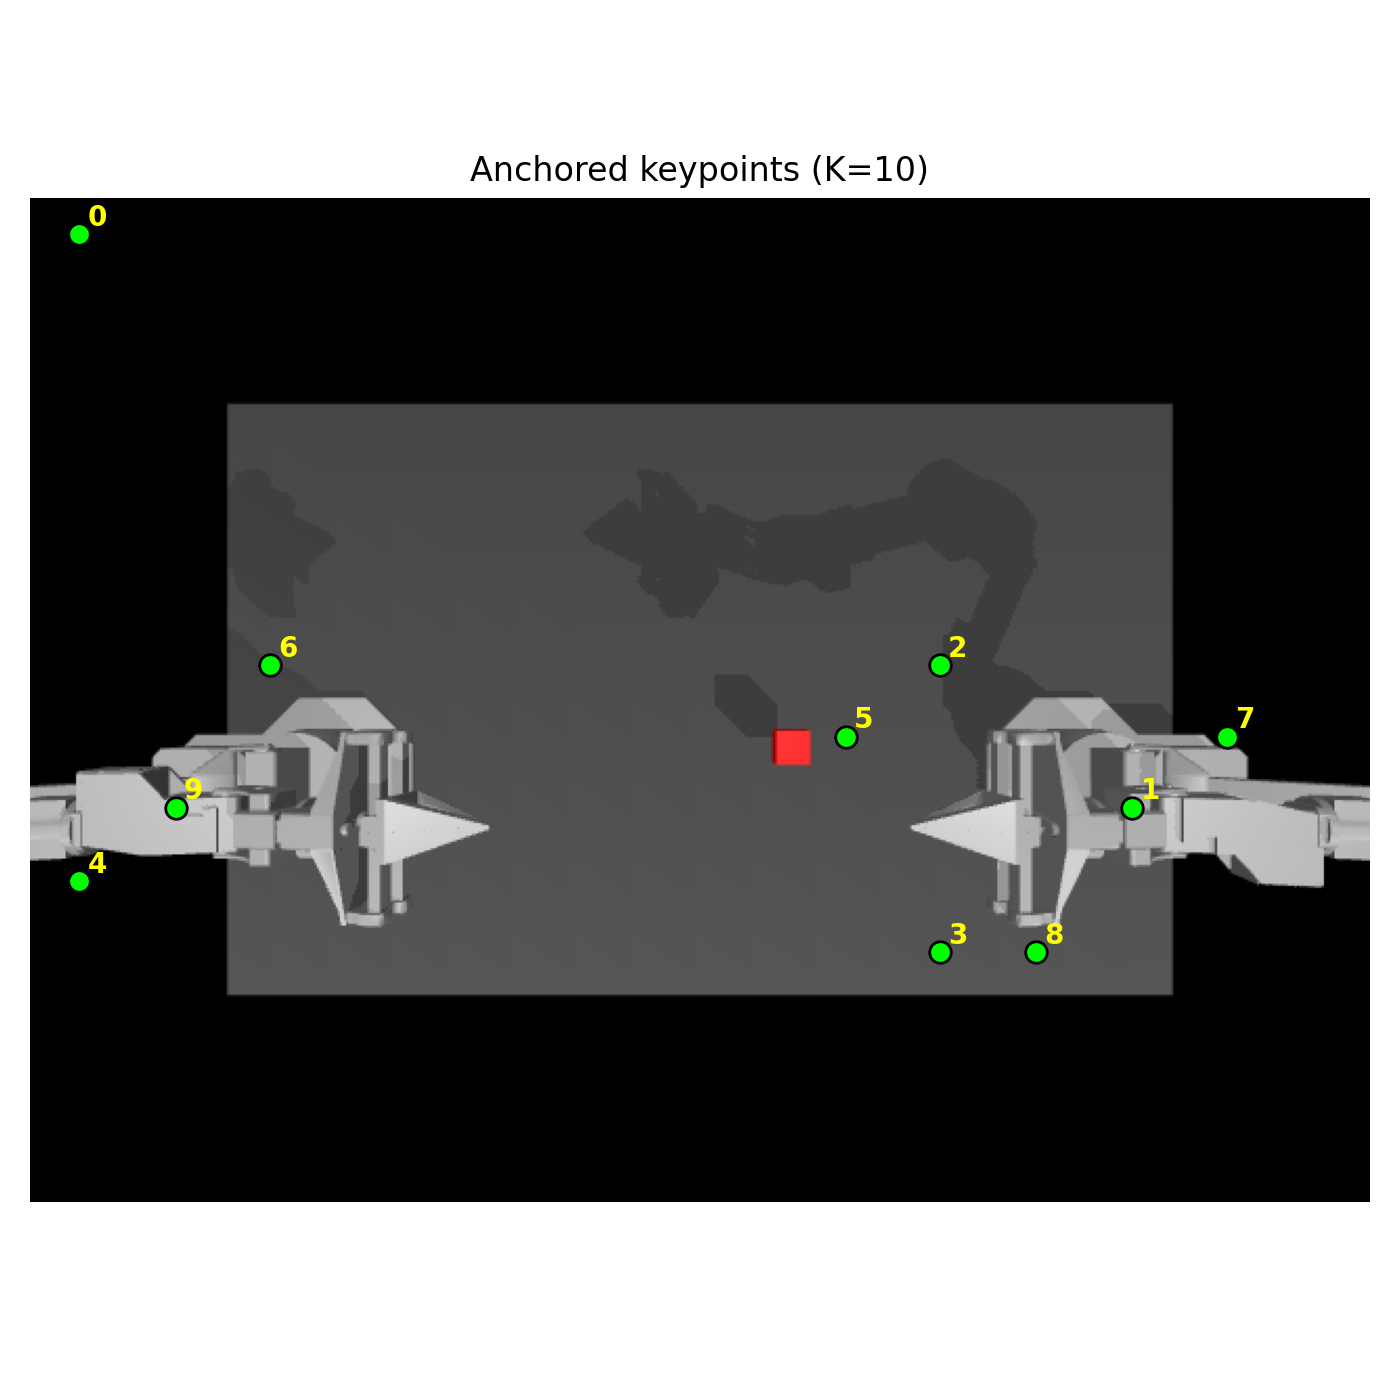

In [7]:
run(f'{ACTIVATE} && python3 scripts/show_tokens.py '
    f'--episode_hdf5 {SUBSETS}/demos_5/episode_0.hdf5 '
    f'--K 10 --M 20 --obs_bins 16 '
    f'--overlay {ARTIFACTS}/keypoints_overlay.png')
show_image(ARTIFACTS / 'keypoints_overlay.png')

In [12]:
run(f'{ACTIVATE} && python3 scripts/gt_replay.py '
    f'--dataset_dir {SUBSETS}/demos_5 '
    f'--out_csv {ARTIFACTS}/results_gt_replay_demos_5.csv '
    f'--save_video --num_save 1')
run(f'{ACTIVATE} && python3 scripts/gt_replay.py '
    f'--dataset_dir {SUBSETS}/test_5 '
    f'--out_csv {ARTIFACTS}/results_gt_replay_test_5.csv '
    f'--save_video --num_save 1')
for csv in sorted(ARTIFACTS.glob('results_gt_replay_*.csv')):
    print('---', csv.name)
    print(csv.read_text())

$ source /Users/sushantsubedi/Documents/act/.venv/bin/activate && python3 scripts/gt_replay.py --dataset_dir /Users/sushantsubedi/Documents/act/data/transfer_cube/subsets/demos_5 --out_csv /Users/sushantsubedi/Documents/act/artifacts/results_gt_replay_demos_5.csv --save_video --num_save 1
  saved video: artifacts/replays/gt_demos_5_ep0.mp4
{
  "dataset_dir": "/Users/sushantsubedi/Documents/act/data/transfer_cube/subsets/demos_5",
  "out_csv": "/Users/sushantsubedi/Documents/act/artifacts/results_gt_replay_demos_5.csv",
  "n": 5,
  "success_rate": 1.0
}
$ source /Users/sushantsubedi/Documents/act/.venv/bin/activate && python3 scripts/gt_replay.py --dataset_dir /Users/sushantsubedi/Documents/act/data/transfer_cube/subsets/test_5 --out_csv /Users/sushantsubedi/Documents/act/artifacts/results_gt_replay_test_5.csv --save_video --num_save 1
  saved video: artifacts/replays/gt_test_5_ep20.mp4
{
  "dataset_dir": "/Users/sushantsubedi/Documents/act/data/transfer_cube/subsets/test_5",
  "out_csv

### Side-by-side: original GT replay vs action-token round-trip

Visual upper-bound sanity check for the **action token representation itself** (no LLM in the loop):

* **First video** — *Original GT replay*: stored `/action` keyframes from `test_5/episode_20.hdf5` linearly upsampled back to 400 sim steps and replayed. Same path `gt_replay.py` exercises across the folder; for a successful demo this is exactly the scripted-policy trajectory.
* **Second video** — *Tokenized → decoded*: take the same full trajectory, subsample **M=20 waypoints**, run them through the per-dim **action quantizer** (`bins=32`), then decode the codes back to floats, linearly upsample to 400 steps, and replay.

The gap between the two videos (and between their `max_reward` values printed below) is the **quantization + waypoint-subsampling loss alone** — what the LLM has to learn to recover.


In [13]:
TEST_EP = 20
M_SANITY = 20
BINS_SANITY = 32
run(rf"""{ACTIVATE} && python3 - <<'PY'
import sys, h5py, numpy as np, json
sys.path.insert(0, '.')
from act_kat.action_tokens import action_tokens_from_episode
from act_kat.icl import fit_quantizer_from_episodes, codes_to_trajectory
from act_kat.episodes import episode_path, list_episode_ids, read_env_state0
from act_kat.replay import replay_actions, upsample_waypoints
from sim_env import BOX_POSE

tests_dir = 'data/transfer_cube/subsets/test_5'
corpus_dir = 'data/transfer_cube/base'
ep_id, M, bins = {TEST_EP}, {M_SANITY}, {BINS_SANITY}

corpus_paths = [episode_path(corpus_dir, e) for e in list_episode_ids(corpus_dir)]
quant = fit_quantizer_from_episodes(corpus_paths, bins=bins)

with h5py.File(episode_path(tests_dir, ep_id), 'r') as r:
    actions = r['/action'][()].astype(np.float32)
    env0 = np.array(r.attrs['env_state0'], dtype=np.float32)
    ds = int(r.attrs.get('downsample_rate', 1))

T_full = int(actions.shape[0]) * max(1, ds)
full = upsample_waypoints(actions, T_full, mode='linear') if ds > 1 else actions[:T_full]

codes, _ = action_tokens_from_episode(full, quantizer=quant, M=M)
traj_dec = codes_to_trajectory(codes, quant, episode_len=T_full, upsample='linear')

BOX_POSE[0] = env0
res = replay_actions(
    traj_dec, episode_len=T_full,
    save_video=True,
    video_path=f'artifacts/replays/decode_test_5_ep{{ep_id}}.mp4',
)
print(json.dumps({{
    'episode_id': ep_id, 'M': M, 'bins': bins, 'T': T_full,
    'success': int(res.success), 'max_reward': float(res.max_reward), 'steps': res.steps,
}}, indent=2))
PY""")

$ source /Users/sushantsubedi/Documents/act/.venv/bin/activate && python3 - <<'PY'
import sys, h5py, numpy as np, json
sys.path.insert(0, '.')
from act_kat.action_tokens import action_tokens_from_episode
from act_kat.icl import fit_quantizer_from_episodes, codes_to_trajectory
from act_kat.episodes import episode_path, list_episode_ids, read_env_state0
from act_kat.replay import replay_actions, upsample_waypoints
from sim_env import BOX_POSE

tests_dir = 'data/transfer_cube/subsets/test_5'
corpus_dir = 'data/transfer_cube/base'
ep_id, M, bins = 20, 20, 32

corpus_paths = [episode_path(corpus_dir, e) for e in list_episode_ids(corpus_dir)]
quant = fit_quantizer_from_episodes(corpus_paths, bins=bins)

with h5py.File(episode_path(tests_dir, ep_id), 'r') as r:
    actions = r['/action'][()].astype(np.float32)
    env0 = np.array(r.attrs['env_state0'], dtype=np.float32)
    ds = int(r.attrs.get('downsample_rate', 1))

T_full = int(actions.shape[0]) * max(1, ds)
full = upsample_waypoints(actio

/Users/sushantsubedi/Documents/act/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


{
  "episode_id": 20,
  "M": 20,
  "bins": 32,
  "T": 400,
  "success": 1,
  "max_reward": 4.0,
  "steps": 400
}


0

In [14]:
import base64
from IPython.display import HTML
left  = ARTIFACTS / 'replays' / f'gt_test_5_ep{TEST_EP}.mp4'
right = ARTIFACTS / 'replays' / f'decode_test_5_ep{TEST_EP}.mp4'
for p in (left, right):
    print('exists:', p.exists(), '->', _rel(p))

def _data_uri(p):
    b64 = base64.b64encode(Path(p).read_bytes()).decode()
    return f'data:video/mp4;base64,{b64}'

left_src  = _data_uri(left)  if left.exists()  else ''
right_src = _data_uri(right) if right.exists() else ''
html = f'''
<div style="display:flex; gap:24px; align-items:flex-start; flex-wrap:wrap;">
  <figure style="margin:0; text-align:center;">
    <video controls width="380" src="{left_src}"></video>
    <figcaption style="margin-top:6px; font-weight:600;">
      Original GT replay &mdash; test_5 / episode {TEST_EP}
    </figcaption>
    <figcaption style="font-size:0.85em; color:#555;">
      stored /action keyframes &rarr; linear upsample &rarr; replay
    </figcaption>
  </figure>
  <figure style="margin:0; text-align:center;">
    <video controls width="380" src="{right_src}"></video>
    <figcaption style="margin-top:6px; font-weight:600;">
      Tokenized &rarr; decoded (M={M_SANITY}, bins={BINS_SANITY})
    </figcaption>
    <figcaption style="font-size:0.85em; color:#555;">
      action quantizer round-trip, no LLM
    </figcaption>
  </figure>
</div>
'''
display(HTML(html))

exists: True -> artifacts/replays/gt_test_5_ep20.mp4
exists: True -> artifacts/replays/decode_test_5_ep20.mp4


## Step 4 — Single ICL smoke test (Ollama → JSON → replay → video)

Runs the **full LLM pipeline once** on a single unseen query (`--max_tests 1`) to confirm Ollama is reachable, the prompt is well-formed, the response parses, and the replay produces an MP4 — all the project rubric's Step 4 requirements in one cell.

All per-query artifacts land under `artifacts/{prompts, responses, replays}/<run_id>.*`.

In [15]:
run(f"{ACTIVATE} && python3 scripts/evaluate.py run "
    f"--demos_dir {SUBSETS}/demos_5 --tests_dir {SUBSETS}/test_5 "
    f"--eval_split unseen --model {OLLAMA_MODEL} "
    f"--K 10 --M 20 --max_tests 1 "
    f"--out_csv {ARTIFACTS}/results_smoke_unseen.csv")
smoke = ARTIFACTS / 'results_smoke_unseen.csv'
if smoke.exists():
    print('---', smoke.name); print(smoke.read_text())

$ source /Users/sushantsubedi/Documents/act/.venv/bin/activate && python3 scripts/evaluate.py run --demos_dir /Users/sushantsubedi/Documents/act/data/transfer_cube/subsets/demos_5 --tests_dir /Users/sushantsubedi/Documents/act/data/transfer_cube/subsets/test_5 --eval_split unseen --model gemma4:26b --K 10 --M 20 --max_tests 1 --out_csv /Users/sushantsubedi/Documents/act/artifacts/results_smoke_unseen.csv


/Users/sushantsubedi/Documents/act/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


[results] /Users/sushantsubedi/Documents/act/artifacts/results_smoke_unseen.csv  split=unseen  K=10 M=20
  [anchors] (10, 384) from /Users/sushantsubedi/Documents/act/data/transfer_cube/subsets/demos_5/episode_0.hdf5
  [unseen] ep=20 demos=[0, 1, 2, 3, 4] -> eval_unseen_demo5_q20_idx0.json
{
  "demos_dir": "/Users/sushantsubedi/Documents/act/data/transfer_cube/subsets/demos_5",
  "tests_dir": "/Users/sushantsubedi/Documents/act/data/transfer_cube/subsets/test_5",
  "eval_split": "unseen",
  "model": "gemma4:26b",
  "collection_seed": 0,
  "K_keypoints": 10,
  "M_actions": 20,
  "bins": 32,
  "obs_bins": 16,
  "n_queries": 1,
  "success_rate_all": 0.0,
  "success_rate_seen": null,
  "success_rate_unseen": 0.0,
  "parse_error_rate": 0.0,
  "avg_gen_time_s": 86.08418416976929,
  "out_csv": "/Users/sushantsubedi/Documents/act/artifacts/results_smoke_unseen.csv"
}
[summary] /Users/sushantsubedi/Documents/act/artifacts/results_smoke_unseen.summary.json
--- results_smoke_unseen.csv
split,epis

In [16]:
# show the most recent ICL rollout video produced by Step 4
icl_videos = sorted((ARTIFACTS / 'replays').glob('eval_*.mp4'), key=lambda p: p.stat().st_mtime, reverse=True)
print('latest ICL rollout videos:')
for v in icl_videos[:3]:
    print(' ', v.name)
if icl_videos:
    show_video(icl_videos[0])

latest ICL rollout videos:
  eval_unseen_demo5_q20_idx0.mp4


## Step 5 — Full sweep: seen + unseen + four ablations + aggregate in one command

Produces, under `artifacts/`:

* `results_main_seen_unseen.csv` — main seen/unseen on `demos_5` (K=10, M=20)
* `results_ablation_ndemos_{10,20}_unseen.csv` — #demos ablation (extra to the 5-demo main config)
* `results_ablation_K{5,10,20}_unseen.csv` — keypoint count ablation
* `results_ablation_M{10,20,40}_unseen.csv` — action-token count ablation
* `results_ablation_model_{gemma4_26b,llama3_2_latest}_unseen.csv` — LLM model ablation (≈26B vs ≈3B)
* `evaluation_summary.json`, `evaluation_tables.md` — aggregated tables

Re-running with the same `--collection_seed` reproduces the same dataset; ICL queries pick the same demo / test episodes deterministically.

In [17]:
MODELS = os.environ.get('OLLAMA_MODELS', 'gemma4:26b,llama3.2:latest')
run(f'{ACTIVATE} && python3 scripts/evaluate.py sweep '
    f'--collection_seed {COLLECTION_SEED} --model {OLLAMA_MODEL} --models "{MODELS}"')

$ source /Users/sushantsubedi/Documents/act/.venv/bin/activate && python3 scripts/evaluate.py sweep --collection_seed 0 --model gemma4:26b --models "gemma4:26b,llama3.2:latest"


/Users/sushantsubedi/Documents/act/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


[results] artifacts/results_main_seen_unseen.csv  split=both  K=10 M=20
  [anchors] (10, 384) from /Users/sushantsubedi/Documents/act/data/transfer_cube/subsets/demos_5/episode_0.hdf5
  [seen] ep=0 demos=[1, 2, 3, 4] -> eval_seen_demo4_q0_idx0.json
  [seen] ep=1 demos=[0, 2, 3, 4] -> eval_seen_demo4_q1_idx1.json
  [seen] ep=2 demos=[0, 1, 3, 4] -> eval_seen_demo4_q2_idx2.json
  [seen] ep=3 demos=[0, 1, 2, 4] -> eval_seen_demo4_q3_idx3.json
  [seen] ep=4 demos=[0, 1, 2, 3] -> eval_seen_demo4_q4_idx4.json
  [unseen] ep=20 demos=[0, 1, 2, 3, 4] -> eval_unseen_demo5_q20_idx5.json
  [unseen] ep=21 demos=[0, 1, 2, 3, 4] -> eval_unseen_demo5_q21_idx6.json
  [unseen] ep=22 demos=[0, 1, 2, 3, 4] -> eval_unseen_demo5_q22_idx7.json
  [unseen] ep=23 demos=[0, 1, 2, 3, 4] -> eval_unseen_demo5_q23_idx8.json
  [unseen] ep=24 demos=[0, 1, 2, 3, 4] -> eval_unseen_demo5_q24_idx9.json
{
  "demos_dir": "/Users/sushantsubedi/Documents/act/data/transfer_cube/subsets/demos_5",
  "tests_dir": "/Users/sushants

0

In [18]:
tables = ARTIFACTS / 'evaluation_tables.md'
if tables.exists():
    display(Markdown(tables.read_text()))
else:
    print(f'(missing: {tables} — run Step 5 above)')

# P5 Step 5 — aggregated results

| CSV | N | Seen SR | Unseen SR | Overall SR | Parse OK |
|-----|--:|--------:|----------:|-----------:|---------:|
| `results_ablation_K10_unseen.csv` | 5 | — | 0.0% | — | 100.0% |
| `results_ablation_K20_unseen.csv` | 5 | — | 0.0% | — | 100.0% |
| `results_ablation_K5_unseen.csv` | 5 | — | 0.0% | — | 100.0% |
| `results_ablation_M10_unseen.csv` | 5 | — | 0.0% | — | 100.0% |
| `results_ablation_M20_unseen.csv` | 5 | — | 0.0% | — | 100.0% |
| `results_ablation_M40_unseen.csv` | 5 | — | 0.0% | — | 0.0% |
| `results_ablation_model_gemma4_26b_unseen.csv` | 5 | — | 0.0% | — | 100.0% |
| `results_ablation_model_llama3_2_latest_unseen.csv` | 5 | — | 0.0% | — | 100.0% |
| `results_ablation_ndemos_10_unseen.csv` | 5 | — | 0.0% | — | 100.0% |
| `results_ablation_ndemos_20_unseen.csv` | 5 | — | 0.0% | — | 100.0% |
| `results_gt_replay_demos_5.csv` | 5 | — | — | 100.0% | 0.0% |
| `results_gt_replay_test_5.csv` | 5 | — | — | 100.0% | 0.0% |
| `results_main_seen_unseen.csv` | 10 | 0.0% | 0.0% | — | 100.0% |
| `results_smoke_unseen.csv` | 1 | — | 0.0% | — | 100.0% |




All artifacts live under `./artifacts/` (videos in `./artifacts/replays/`). The accompanying report file discusses the method, results, ablation findings, and failure cases.